## Probabilistic Modeling of A/B Compartments from E1

This model infers A/B chromatin compartment structure from the first eigenvector (E1) of the Hi-C contact matrix using a Bayesian framework.

### Goals
- Replace hard sign-thresholding of E1 with a probabilistic compartment assignment.
- Quantify uncertainty in compartment calls for each genomic bin.
- Allow for modeling of missing E1 values due to low signal.

### Assumptions
- Each bin belongs to one of two latent states: A or B compartment.
- E1 values are generated from Gaussian distributions specific to each compartment.
- Prior belief: A has positive E1 values (μ ≈ 0.5), B has negative (μ ≈ -0.5).
- Bins are initially treated as independent
- Spatial depency can be added later (HMM)


### The data

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
from scipy.stats import norm


%config InlineBackend.figure_format = 'retina'



In [17]:


# Input: csv file with only the E1 columns

# Low res example
resolution = 100000

y = pd.Series(pd.read_csv(f"../data/eigs/fibroblast.eigs.{resolution}.cis.vecs.tsv", sep="\t")['E1'].values.flatten())
bins = np.arange(0, y.shape[0])
x = pd.Series(bins*resolution)

# Make a DataFrame object
df = pd.DataFrame({"bin": bins,
                   "start": x, 
                   "e1": y})
df.set_index("bin", inplace=True)

df.dropna(inplace=True)

display(df)

,start,e1
bin,,
24,2400000,0.922314
25,2500000,0.932528
26,2600000,0.756230
27,2700000,0.816144
28,2800000,1.082757
...,...,...
1617,161700000,0.006918
1618,161800000,0.007641
1619,161900000,-0.026140


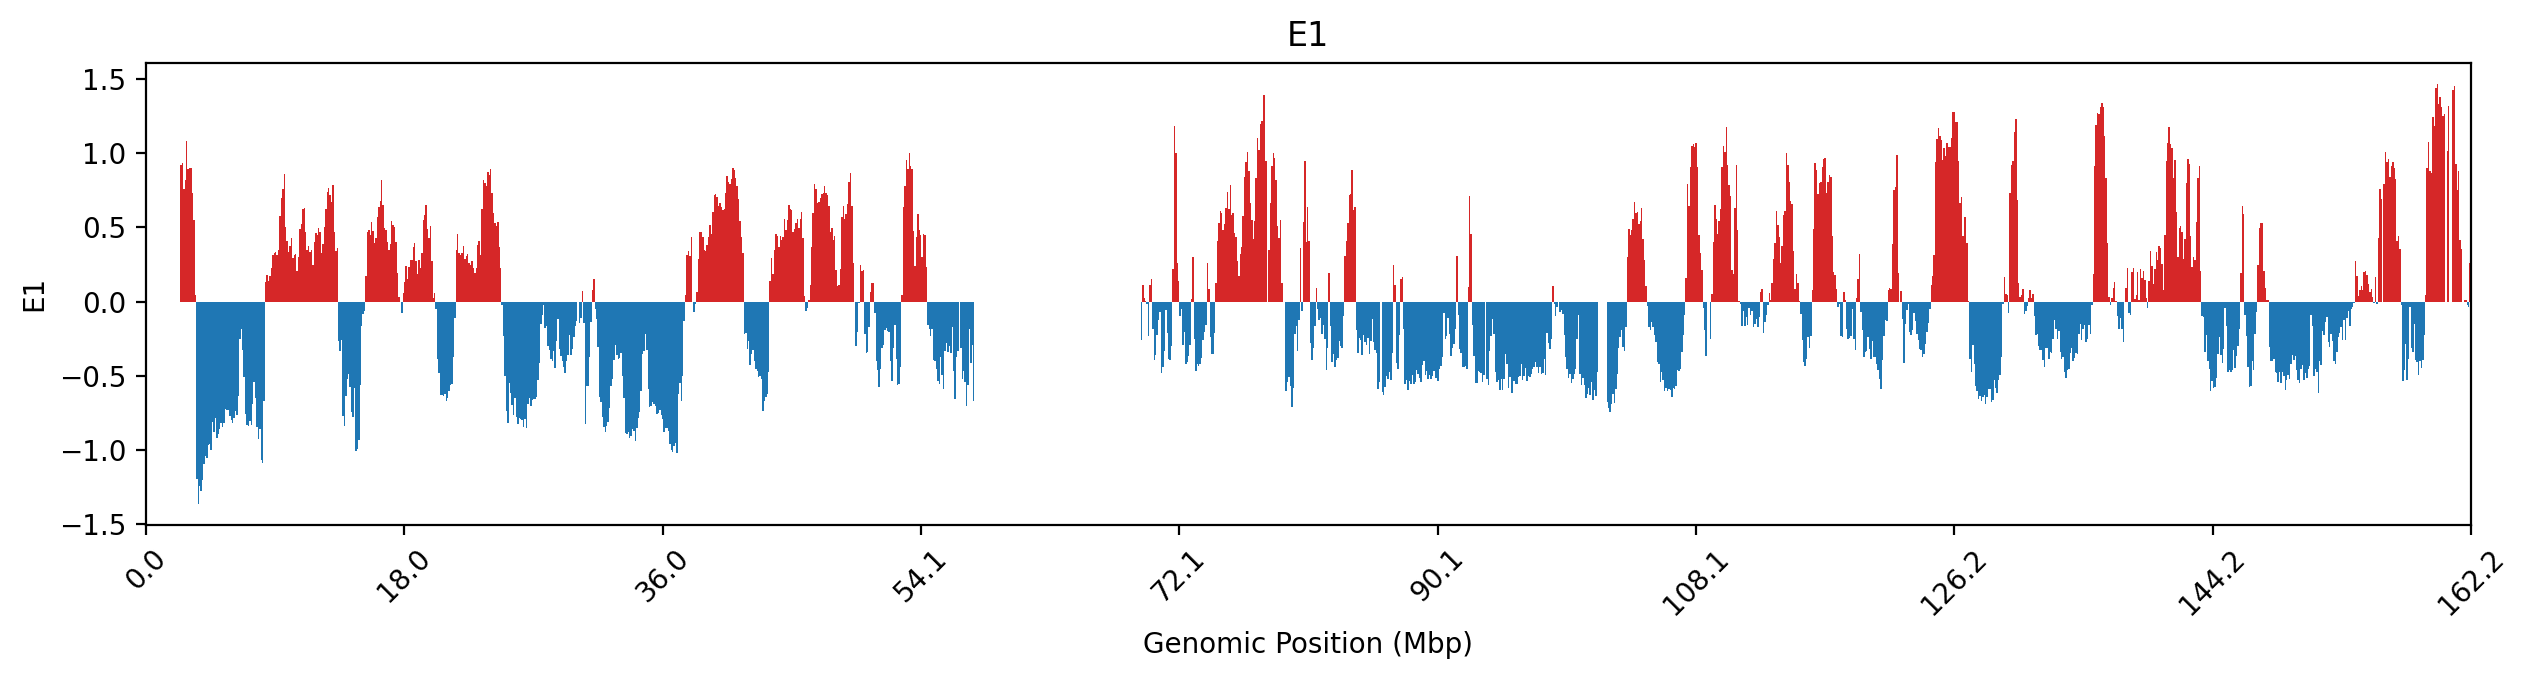

In [18]:
# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots(figsize=(15, 3))

x_stair = np.zeros(2*y.shape[0])
y_stair = np.zeros(2*y.shape[0])
x_stair[0::2] = x
x_stair[1::2] = x + resolution
y_stair[0::2] = y
y_stair[1::2] = y

ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", ec='None')

ax.set_xlim(0, df["start"].max()+resolution)
ticks = np.linspace(0, df["start"].max()+resolution, num=10)
ax.set_xticks(ticks)
ax.set_xticklabels(np.round(ticks / 1e6, 1), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1");

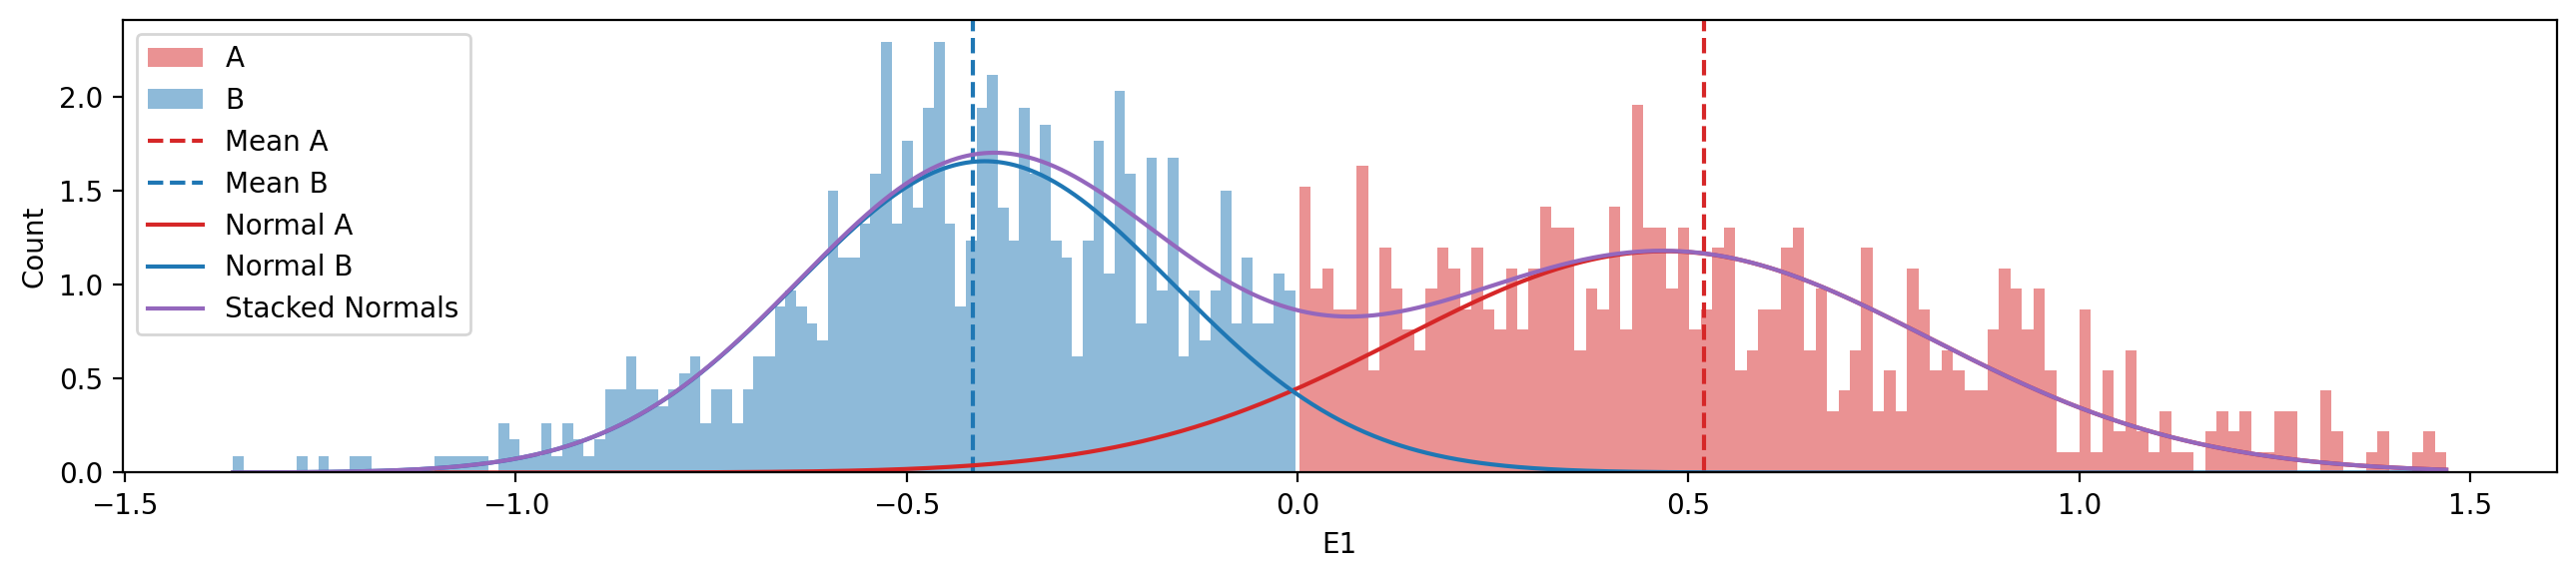

In [19]:
# Histogram of distribution of E1 values (A and B)

f, ax = plt.subplots(figsize=(13, 3))

# A compartments
ax.hist(y[y>0], bins=100, color="tab:red", alpha=0.5, label="A", density=True)
# B compartments
ax.hist(y[y<0], bins=100, color="tab:blue", alpha=0.5, label="B", density=True)
# Mean values (vline)
ax.axvline(y[y>0].mean(), color="tab:red", linestyle="--", label="Mean A")
ax.axvline(y[y<0].mean(), color="tab:blue", linestyle="--", label="Mean B")

# Plot the normal distributions
x_values = np.linspace(y.min(), y.max(), 1000)
mean_a = y[y>0].median()
mean_b = y[y<0].median()
std_a = y[y>0].std()
std_b = y[y<0].std()


ax.plot(x_values, norm.pdf(x_values, loc=mean_a, scale=std_a), color="tab:red", label="Normal A")
ax.plot(x_values, norm.pdf(x_values, loc=mean_b, scale=std_b), color="tab:blue", label="Normal B")
stacked = norm.pdf(x_values, loc=mean_a, scale=std_a) + norm.pdf(x_values, loc=mean_b, scale=std_b)
ax.plot(x_values, stacked, color="tab:purple", label="Stacked Normals")

plt.xlabel("E1")
plt.ylabel("Count")
plt.legend(loc='upper left')
plt.tight_layout()

### Model Specification

Before specifying the model, we need to layout the model structure. 

The model is a mixture of two Gaussian distributions, one for each compartment (A and B). Then a latent variable indicates the compartment assignment for each bin. More formally;

#### Description

We aim to model the A/B chromatin compartments using a probabilistic generative approach, rather than relying on deterministic eigenvector sign thresholding. Each genomic bin is modeled as belonging to one of two latent states (A or B), with corresponding expected E1 values.


##### Notation

Let:

- $y_i$: Observed E1 value at bin $i$ 
- $z_i \in \{0, 1\}$: Latent compartment assignment (0 = B, 1 = A)
- $\mu_A, \mu_B$: Mean E1 values for compartments A and B
- $\sigma$: Shared standard deviation across bins
- $p$: Prior probability of a bin belonging to compartment A


##### Model variables

$$
\begin{aligned}
\mu_A &\sim \mathcal{N}(0.5, 0.5) \\
\mu_B &\sim \mathcal{N}(-0.5, 0.5) \\
\sigma &\sim \text{HalfNormal}(1) \\
p &\sim \text{Beta}(a, b) \quad \text{(e.g., } a = 2, b = 2 \text{ or something bimodal)} \\
z_i &\sim \text{Bernoulli}(p) \\
\mu_i &= z_i \cdot \mu_A + (1 - z_i) \cdot \mu_B \\
y_i &\sim \mathcal{N}(\mu_i, \sigma) \\
\end{aligned}
$$


This model allows us to infer both the compartment state and the uncertainty of the assignment, especially around boundaries between A and B compartments.




##### The Priors

- **$\mu_A$ and $\mu_B$**: We assume that the mean E1 values for compartments A and B are normally distributed around 0.5 and -0.5, respectively, with a standard deviation of 0.5. This reflects our prior belief about the expected E1 values for each compartment.
- **$\sigma$**: The standard deviation is modeled using a half-normal distribution, which ensures that it is always positive. This allows for flexibility in modeling the variability of E1 values within each compartment.
- **$p$**: The prior probability of a bin belonging to compartment A is modeled using a Beta distribution. This allows us to incorporate prior beliefs about the expected proportion of bins in each compartment. The parameters $a$ and $b$ can be adjusted to reflect different prior beliefs (e.g., bimodal distributions).
- **$z_i$**: The latent variable indicating the compartment assignment for each bin is modeled using a Bernoulli distribution, with the probability of being in compartment A given by $p$.
- **$y_i$**: The observed E1 values are modeled as normally distributed around the mean E1 value for the assigned compartment, with a shared standard deviation $\sigma$.
This generative model allows us to infer the compartment assignments and their associated uncertainties based on the observed E1 values, while also accounting for the variability in the data.

Let's look at a few different options for the Beta distribution. There are 3 main options:

- **Uniform**: $a = 1, b = 1$ (no prior preference for A or B)
- **Bimodal**: $a = 0.5, b = 0.5$ (most observations are certain to belong to A or B, but a few observations are hard to categorize—borders)
- **Unimodal**: $a = 2, b = 2$ (most obsevations are hard to categorize)

Here, they are visualized:

Sampling: [p]
Sampling: [p]
Sampling: [p]


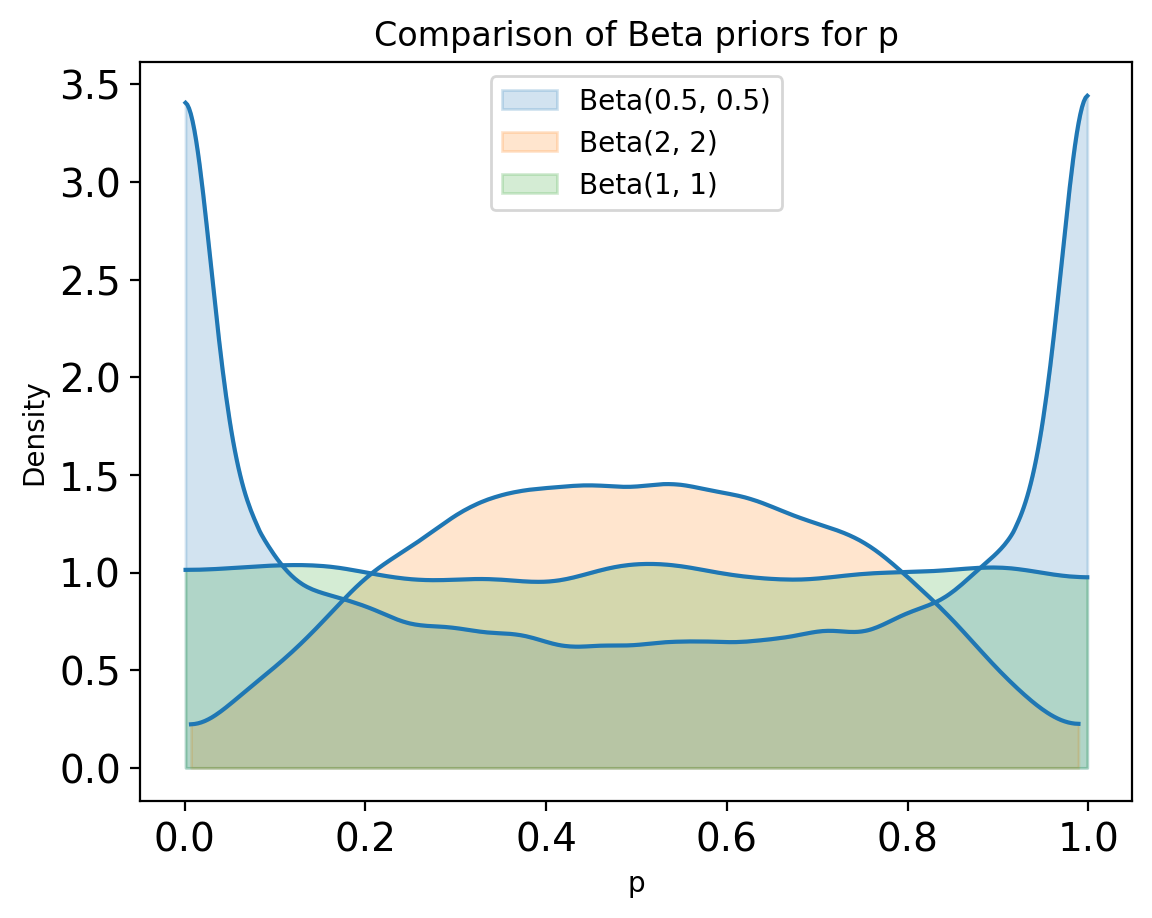

In [20]:
# First, have a look at different Beta distributions for the prior on the latent state (z)

fig, ax = plt.subplots()

params = [(0.5, 0.5), (2, 2), (1, 1)]
colors = ["tab:blue", "tab:orange", "tab:green"]

for (a, b),col in zip(params, colors):
    with pm.Model() as model:
        p = pm.Beta("p", alpha=a, beta=b)
        prior = pm.sample_prior_predictive(samples=10000)
        az.plot_kde(prior.prior["p"].values, label=f"Beta({a}, {b})", ax=ax, fill_kwargs={"alpha": 0.2, "color":col})

ax.set_title("Comparison of Beta priors for p")
ax.set_xlabel("p")
ax.set_ylabel("Density")
ax.legend()
plt.show()



~~I find that the most useful prior is the bimodal one, as we have a strong prior belief that most bins are either A or B, but a few bins are hard to categorize. This is especially useful for the edges of compartments, where the E1 values are close to 0. The unimodal prior is not very useful, as it assumes that most bins are hard to categorize, which is not the case in our data. The uniform prior could be useful as the most uninformative prior —the least biased.*~~

Above logic is flawed. This is not what the prior is reflecting. A Beta(0.5, 0.5) prior assumes that a data set is most likely consisting of only A or B compartments. Therefore, we need Beta(2,2) to reflect that compartments are expected to of both A and B. 

Sampling: [nu_exp, nu_norm]
Sampling: [nu_exp, nu_norm]
Sampling: [nu_exp, nu_norm]


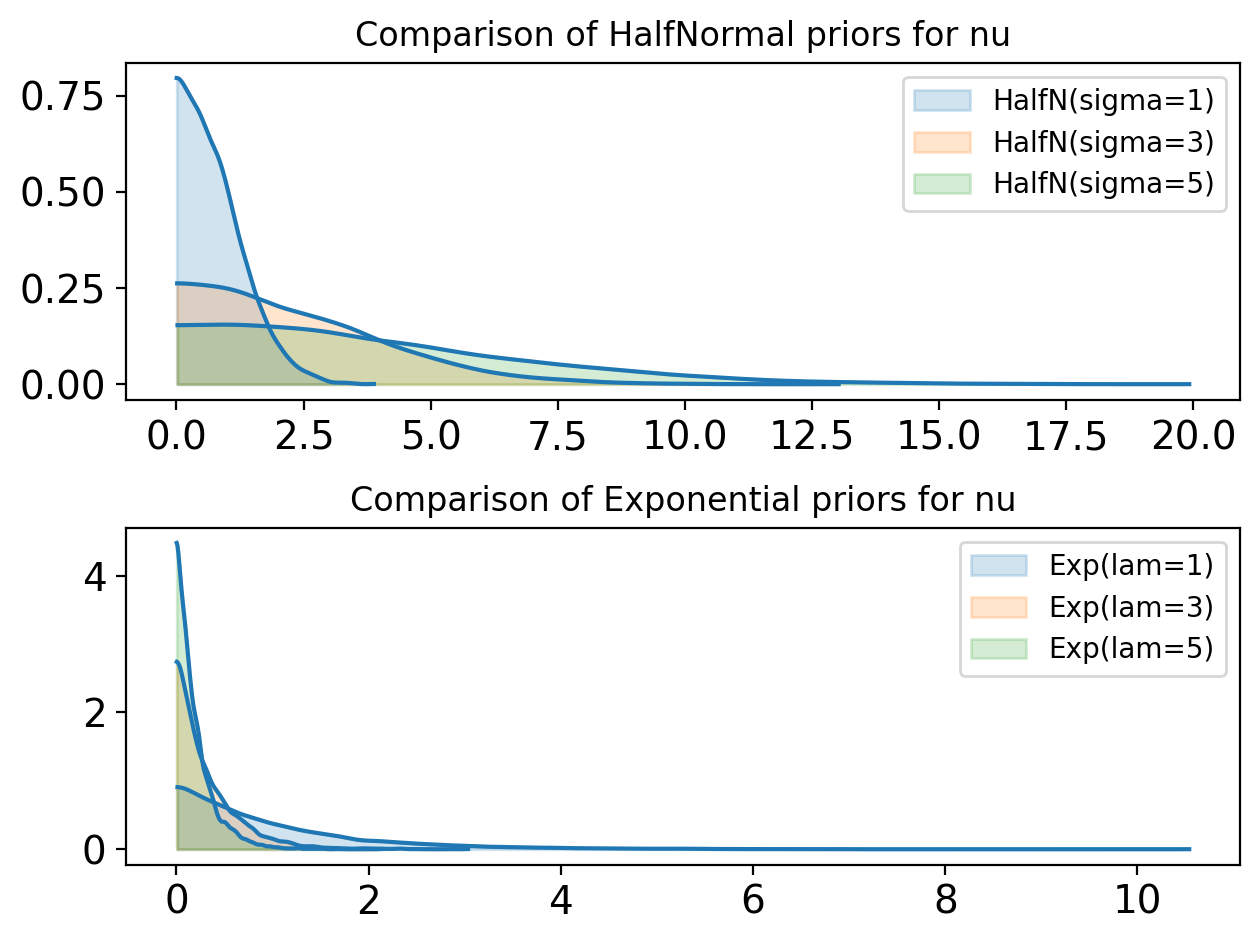

In [21]:
fig, ax = plt.subplots((2))

#params = [(0.5, 0.5), (2, 2), (1, 1)]
params = [(1,0), (3,0), (5,0)]
colors = ["tab:blue", "tab:orange", "tab:green"]

for (a, b),col in zip(params, colors):
    with pm.Model() as ylik_priors:
        nu_norm = pm.HalfNormal("nu_norm", sigma=a)
        nu_exp = pm.Exponential("nu_exp", lam=a)
        prior = pm.sample_prior_predictive(samples=10000)
        ax[0].set_title("Comparison of HalfNormal priors for nu")
        az.plot_kde(prior.prior["nu_norm"].values, label=f"HalfN(sigma={a})", ax=ax[0], fill_kwargs={"alpha": 0.2, "color":col})
        ax[1].set_title("Comparison of Exponential priors for nu")
        az.plot_kde(prior.prior["nu_exp"].values, label=f"Exp(lam={a})", ax=ax[1], fill_kwargs={"alpha": 0.2, "color":col})

plt.tight_layout()

### Model in PyMC

In [22]:
coords = {"bins": df.index.values,
          "pos": df.start.values}

with pm.Model(coords=coords) as model:
    # Let the model be aware of the data
    ## Cannot be done with missing values or masked arrays
    # e1 = pm.Data("e1", df.e1.values, dims="bins")

    # Two means for A and B compartments
    mu_a = pm.Normal("mu_a", 0.5, 0.3)
    mu_b = pm.Normal("mu_b", -0.5, 0.3)

    # Standard deviation for the noise (only positive values HalfStudent)
    sigma = pm.HalfNormal("sigma", 0.3)

    # Latent state for each bin: 1 = A, 0 = B
    p = pm.Beta("p", 2, 2, dims="bins")  

    # Latent state variable z, indicating whether a bin is A or B
    z = pm.Bernoulli("z", p=p, dims="bins")

    # per-bin expected mean
    mu = pm.math.switch(z, mu_a, mu_b) 


    # Likelihood estimate 
    y_lik = pm.Normal("y_lik", mu=mu, sigma=sigma, observed=df.e1.values, dims="bins")


Let's overwrite the model with an alternative that does not try to infer the actual state (Bernoulli part), but only draws the mean value from a Beta dist. Then, the model draw the E1 values from a mixture of `mu_a` and `mu_b` with the weights given by the probabiliy `w` (`w` and `1-w`). This could be more accurate, and also it will be much faster to sample from, as we do not need to sample the latent variable `z_i` for each bin which is using a really slow BinaryMetropolisHastings sampler. 

In [23]:
with pm.Model(coords={"pos": df.index.values}) as model:

    # mu_a = pm.Normal("mu_a", 0.5, 0.3)
    # mu_b = pm.Normal("mu_b", -0.5, 0.3)
    # sigma = pm.HalfNormal("sigma", 0.3)
    # New: Make ordered parameters for mu_a and mu_b in stead
    mu = pm.Normal("mu", mu=[-0.5, 0.5], sigma=0.3,
        transform=pm.distributions.transforms.ordered, # IMPORTANT
        shape=2,
        )
    sigma = pm.HalfNormal("sigma", 0.1, shape=2)

    w = pm.Beta("w", 1, 1) 

    # components = pm.Normal.dist(mu = pm.math.stack([mu_a, mu_b]), sigma = sigma, shape=(2,))
    # New: Use the ordered mu parameters (cleaner code as well)
    components = pm.Normal.dist(mu=mu, sigma=sigma, shape=2)

    # Likelihood estimate
    y_lik = pm.Mixture("y_lik", w=[w,1-w], comp_dists=components, observed=df.e1.values)


Right, let's rewrite it again, so that the model uses a switch again, but this time based on the latent probability og being in A.

In [24]:
coords = {"bins": df.index.values,
          "pos": df.start.values}

with pm.Model(coords=coords) as model_inactive:
    # Let the model be aware of the data
    ## Cannot be done with missing values or masked arrays
    #e1 = pm.Data("e1", df.e1.dropna().values, dims="bins")

    # Two means for A and B compartments
    mu_a = pm.Normal("mu_a", 0.5, 0.3)
    mu_b = pm.Normal("mu_b", -0.5, 0.3)

    # Standard deviation for the noise (only positive values HalfStudent)
    sigma = pm.HalfNormal("sigma", 0.3)

    # Latent state for each bin: 1 = A, 0 = B
    p = pm.Beta("p", 2, 2, dims="bins")  

    # per-bin expected mean
    mu = pm.math.switch(p > 0.5, mu_a, mu_b) 

    # Likelihood estimate 
    y_lik = pm.Normal("y_lik", mu=mu, sigma=sigma, observed=df.e1.values, dims="bins")


#### Model graphs

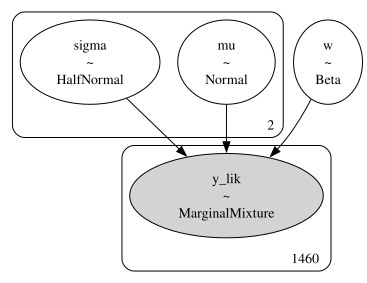

In [25]:
# Visualize
model_graph = pm.model_to_graphviz(model)
#model_graph

model.to_graphviz()


#### Test the priors

In [26]:
with model:
    # Sample from the prior
    trace = pm.sample_prior_predictive(samples=1000)

trace

Sampling: [mu, sigma, w, y_lik]


Inference data with groups:
	> prior
	> prior_predictive
	> observed_data

In [27]:
prior_predictive_e1 = az.extract(trace, group="prior_predictive", var_names=["y_lik"])

print(f"""
y_lik (min, max, std): {prior_predictive_e1.values.min(), prior_predictive_e1.values.max(), prior_predictive_e1.values.std()}
""")

#y_lik_norm (min, max, std): {prior_predictive_e1.y_lik_norm.values.min(), prior_predictive_e1.y_lik_norm.values.max(), prior_predictive_e1.y_lik_norm.values.std()}


y_lik (min, max, std): (np.float64(-1.9425954364288853), np.float64(1.8550935277537985), np.float64(0.5732486808112708))



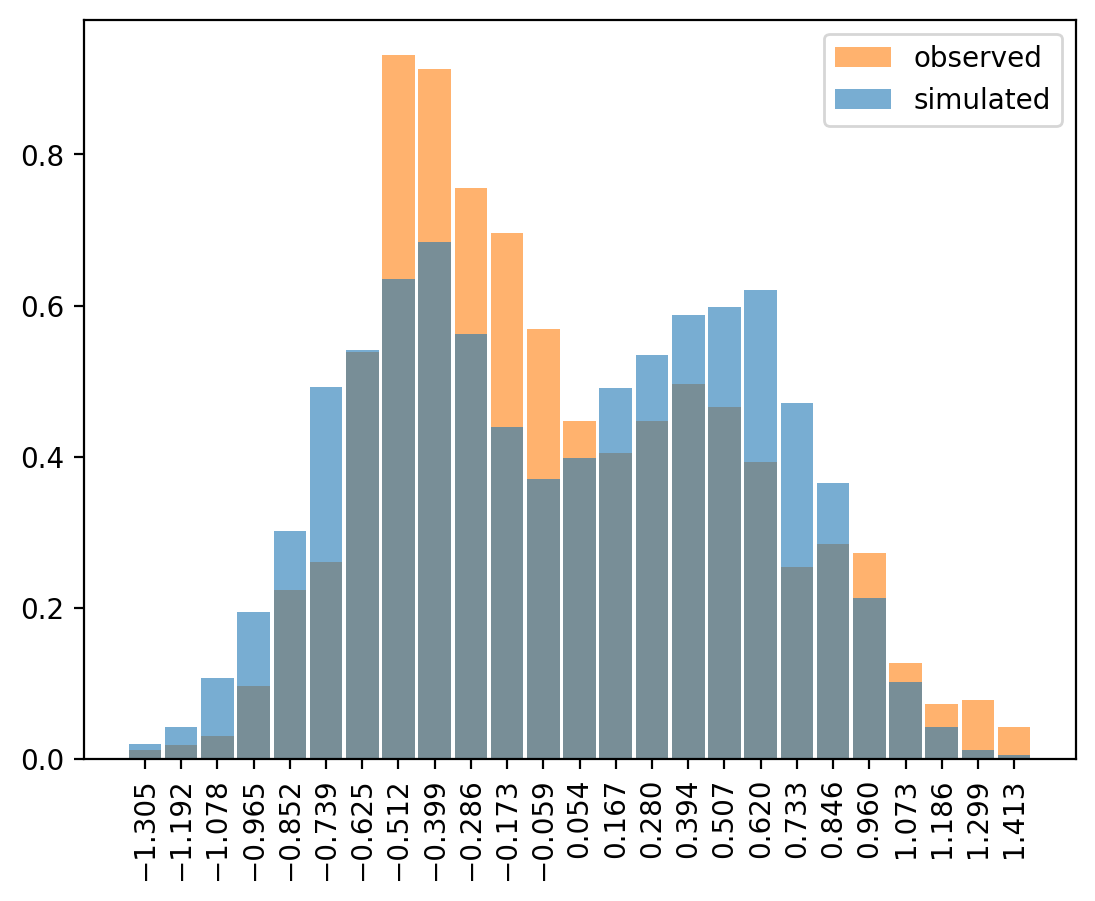

In [28]:
e1_obs = df['e1'].dropna().values

az.plot_dist(
    e1_obs,
    kind="hist",
    color="C1", 
    hist_kwargs={"alpha": 0.6,  "bins": 25},
    label="observed"
)



prior_pred_obs = trace.prior_predictive["y_lik"].stack(sample=("chain", "draw")).values
prior_pred_obs = prior_pred_obs[prior_pred_obs > e1_obs.min()]  # Constrain the range to observed values
prior_pred_obs = prior_pred_obs[prior_pred_obs < e1_obs.max()]  # Constrain the range to observed values

az.plot_dist(
    prior_pred_obs,
    kind="hist",
    hist_kwargs={"alpha": 0.6, "bins":25},
    label="simulated",
)
plt.xticks(rotation=90);



~~This was quite involved to get to plot, as the prior predictions take values between -Inf and Inf. It could mean that the priors are not super robust to the random variables defining the StudentT draws from `y_lik`: If the `nu` or `sigma` draws are too small, the T-dist could become numerically unstable and produce Inf values.~~

With y_lik adhering to a Normal distribution, there are no infinites, and the range is more narrow. That must mean something to the predicitions as well, but I'm not quite sure about the effect. 

#### Posterior sampling

Here, we both create a trace (by sampling) and then sample from the predictive posterior. 

In [29]:
with model:
    # Sample from the posterior
    trace = pm.sample(2000, tune=2000, cores=4, chains=4, target_accept=0.9, 
                    #   step = [
                    #       pm.NUTS([mu_a, mu_b, sigma, p], target_accept=0.9),
                    #       pm.BinaryGibbsMetropolis([z], transit_p=0.8)], 
                        #   nuts_sampler='nutpie'
                    )


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, w]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 7 seconds.


In [30]:

with model:
    pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Sampling: [y_lik]


Output()

In [31]:
with model:
    prior_pred = pm.sample_prior_predictive(samples=1000)
trace.extend(prior_pred)

Sampling: [mu, sigma, w, y_lik]


In [32]:
with model: 
    pm.compute_log_likelihood(trace, extend_inferencedata=True)

Output()

#### Evaluation 

We now have some variables that are fitted and all have a posterior distribution. 

Which ones are interesting? Well, the `p` represents the probability $p \in [0;1]$ for a bin to be in compartment A (remember, A is 1, and B is 0). `z` is the actual compartment assignment $z \in \{0, 1\}$, where $z \sim \mathcal{Bernoulli}(p) = \mathcal{B}(1,p)$. `y` is the observed E1 value drawn from a Normal distribution with the fitted mu and sigma.

In [33]:
trace

Inference data with groups:
	> posterior
	> posterior_predictive
	> log_likelihood
	> sample_stats
	> prior
	> prior_predictive
	> observed_data

Let's do some stuff on the log-likelihood of the posterior. We can use arviz to generate Leave-One-Out (LOO) cross-validation

In [34]:
model_loo = az.loo(trace)
model_loo

Computed from 8000 posterior samples and 1460 observations log-likelihood matrix.

         Estimate       SE
elpd_loo -1083.86    25.06
p_loo        4.97        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)     1460  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

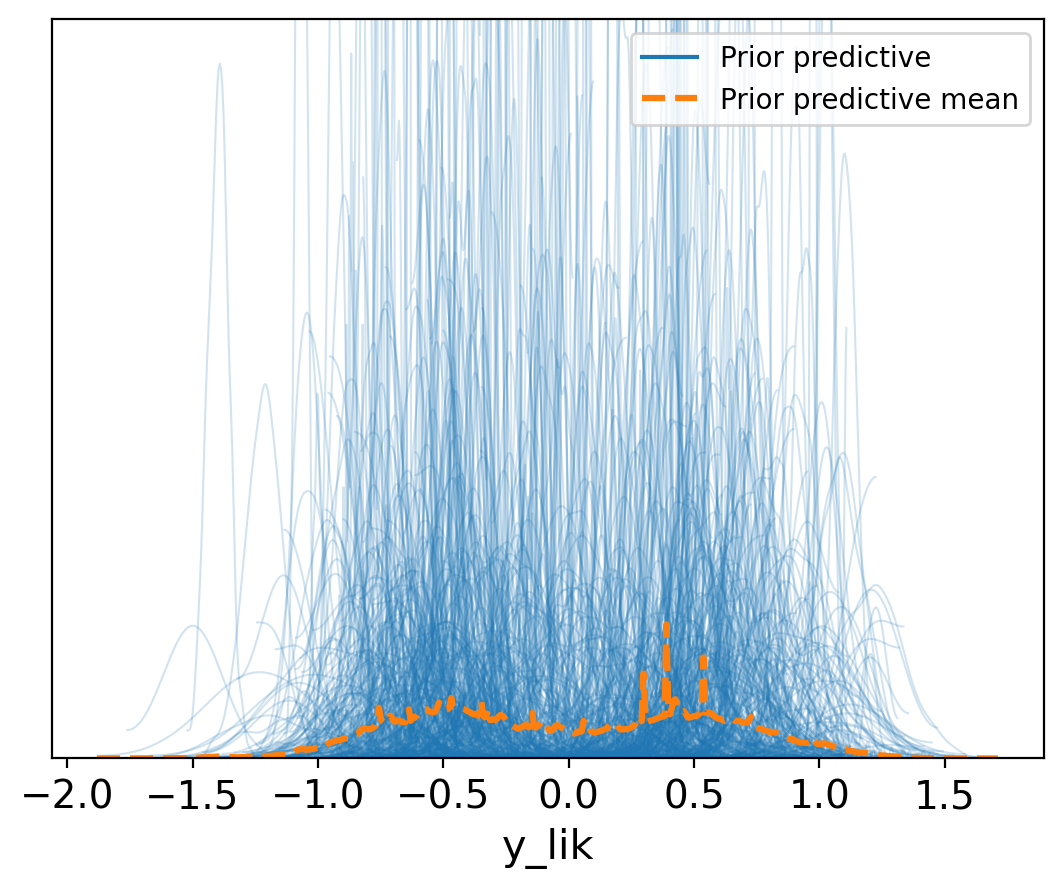

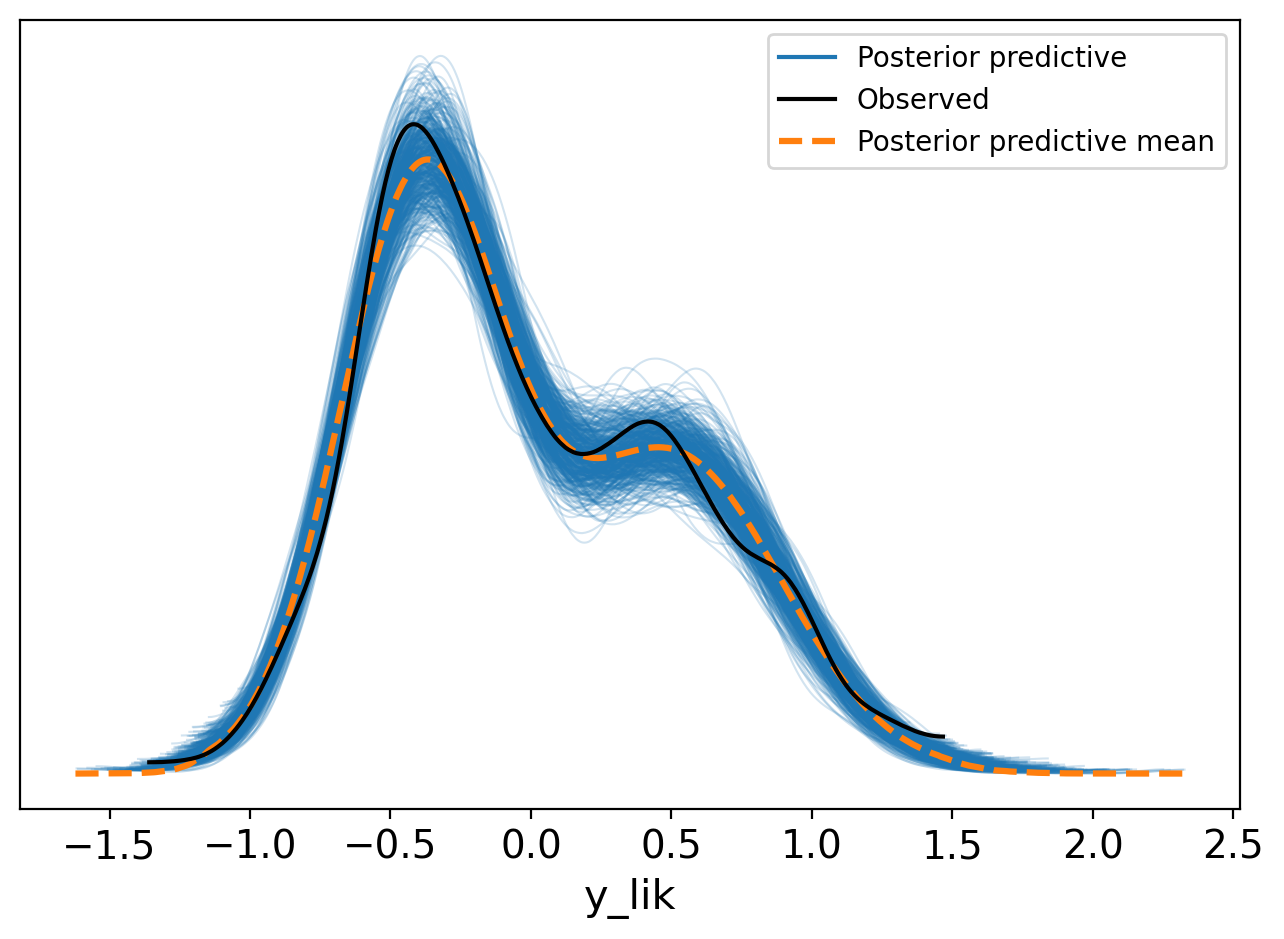

In [35]:
az.plot_ppc(trace, num_pp_samples=500, group="prior", data_pairs={"y_lik": "y_lik"});
plt.legend(loc="upper right")
plt.ylim(0,10);
az.plot_ppc(trace, num_pp_samples=500, group="posterior");
plt.legend(loc="upper right")
plt.tight_layout()

> Slight deviation near 1 in the posterior predictive distribution suggests possible additional states, but the model otherwise captures the main features of the E1 distribution.

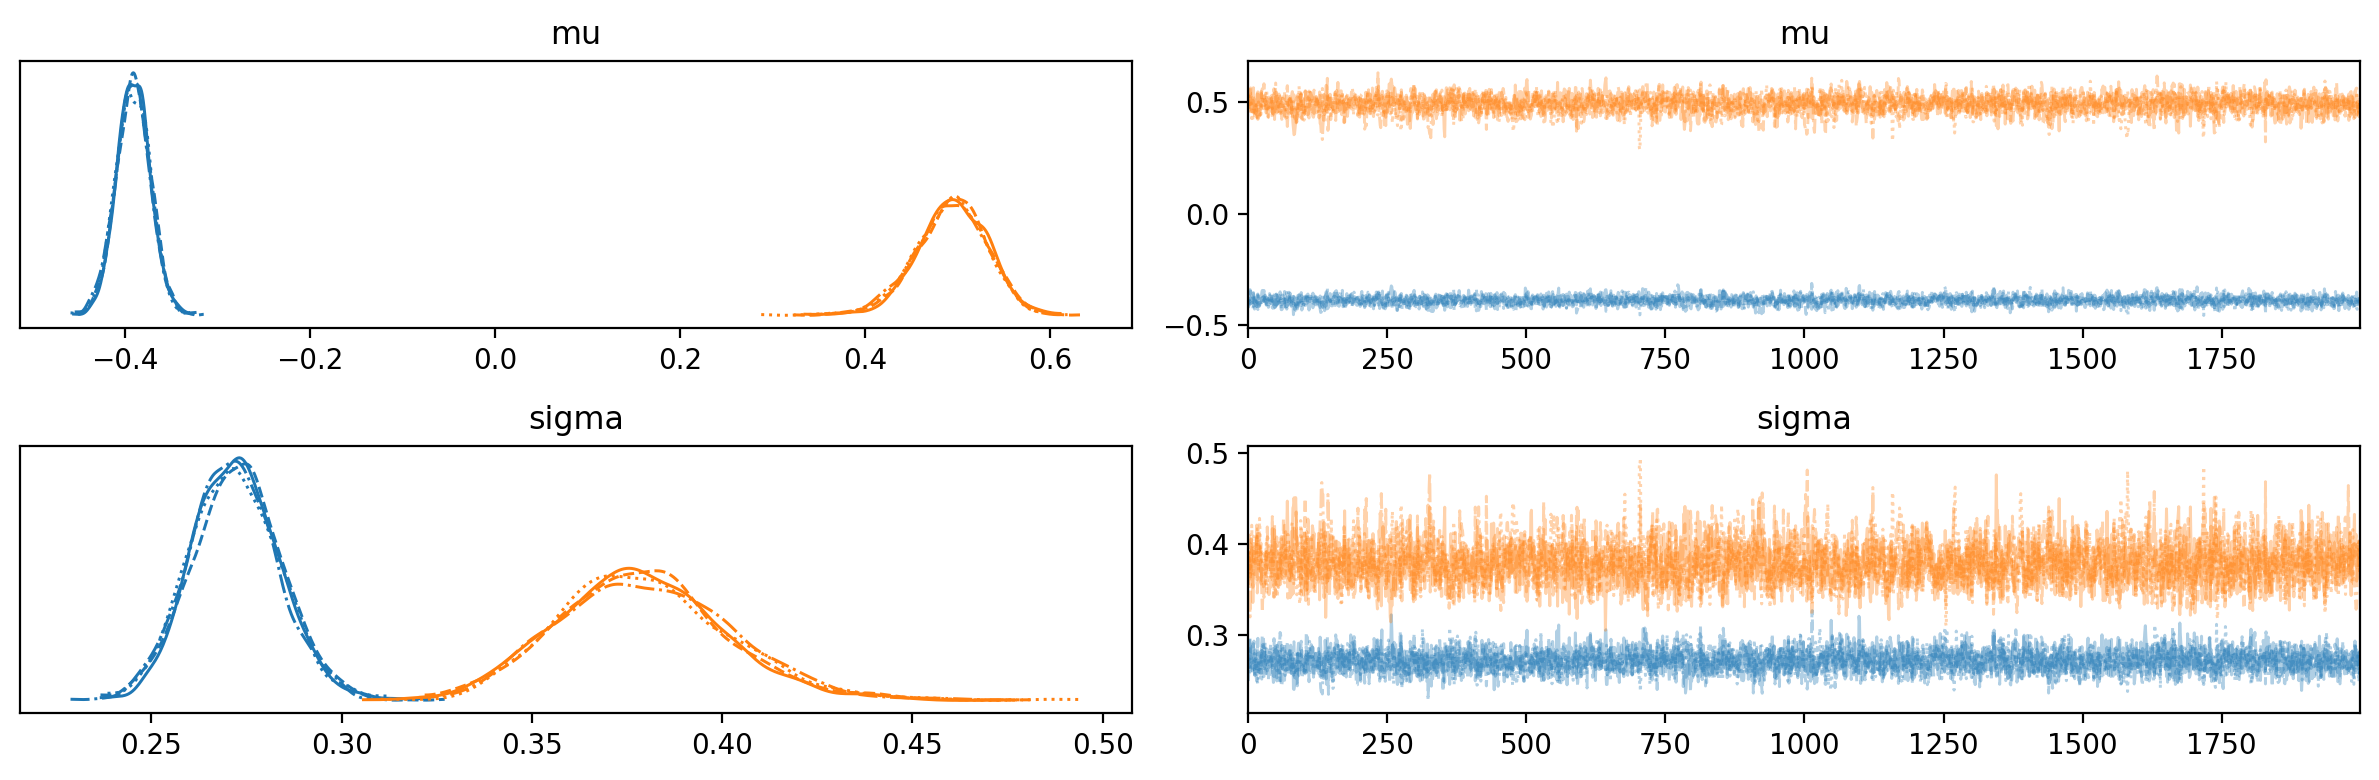

In [38]:
az.plot_trace(trace, var_names=["mu", 'sigma'], compact=True, backend_kwargs={'layout': 'tight'});

In [39]:
trace_ylik = az.summary(trace, var_names=['y_lik'], kind='stats', group='posterior_predictive')


In [40]:
trace_ylik


,mean,sd,hdi_3%,hdi_97%
y_lik[0],-0.014,0.551,-0.875,1.024
y_lik[1],-0.017,0.544,-0.902,0.978
y_lik[2],-0.015,0.548,-0.901,0.978
y_lik[3],-0.024,0.542,-0.859,1.011
y_lik[4],-0.016,0.546,-0.849,1.027
...,...,...,...,...
y_lik[1455],-0.015,0.542,-0.886,0.984
y_lik[1456],-0.021,0.549,-0.863,1.026
y_lik[1457],-0.017,0.538,-0.895,0.963
y_lik[1458],-0.010,0.545,-0.871,1.018


        mean      sd
means -0.015  0.5433
sds    0.006  0.0036


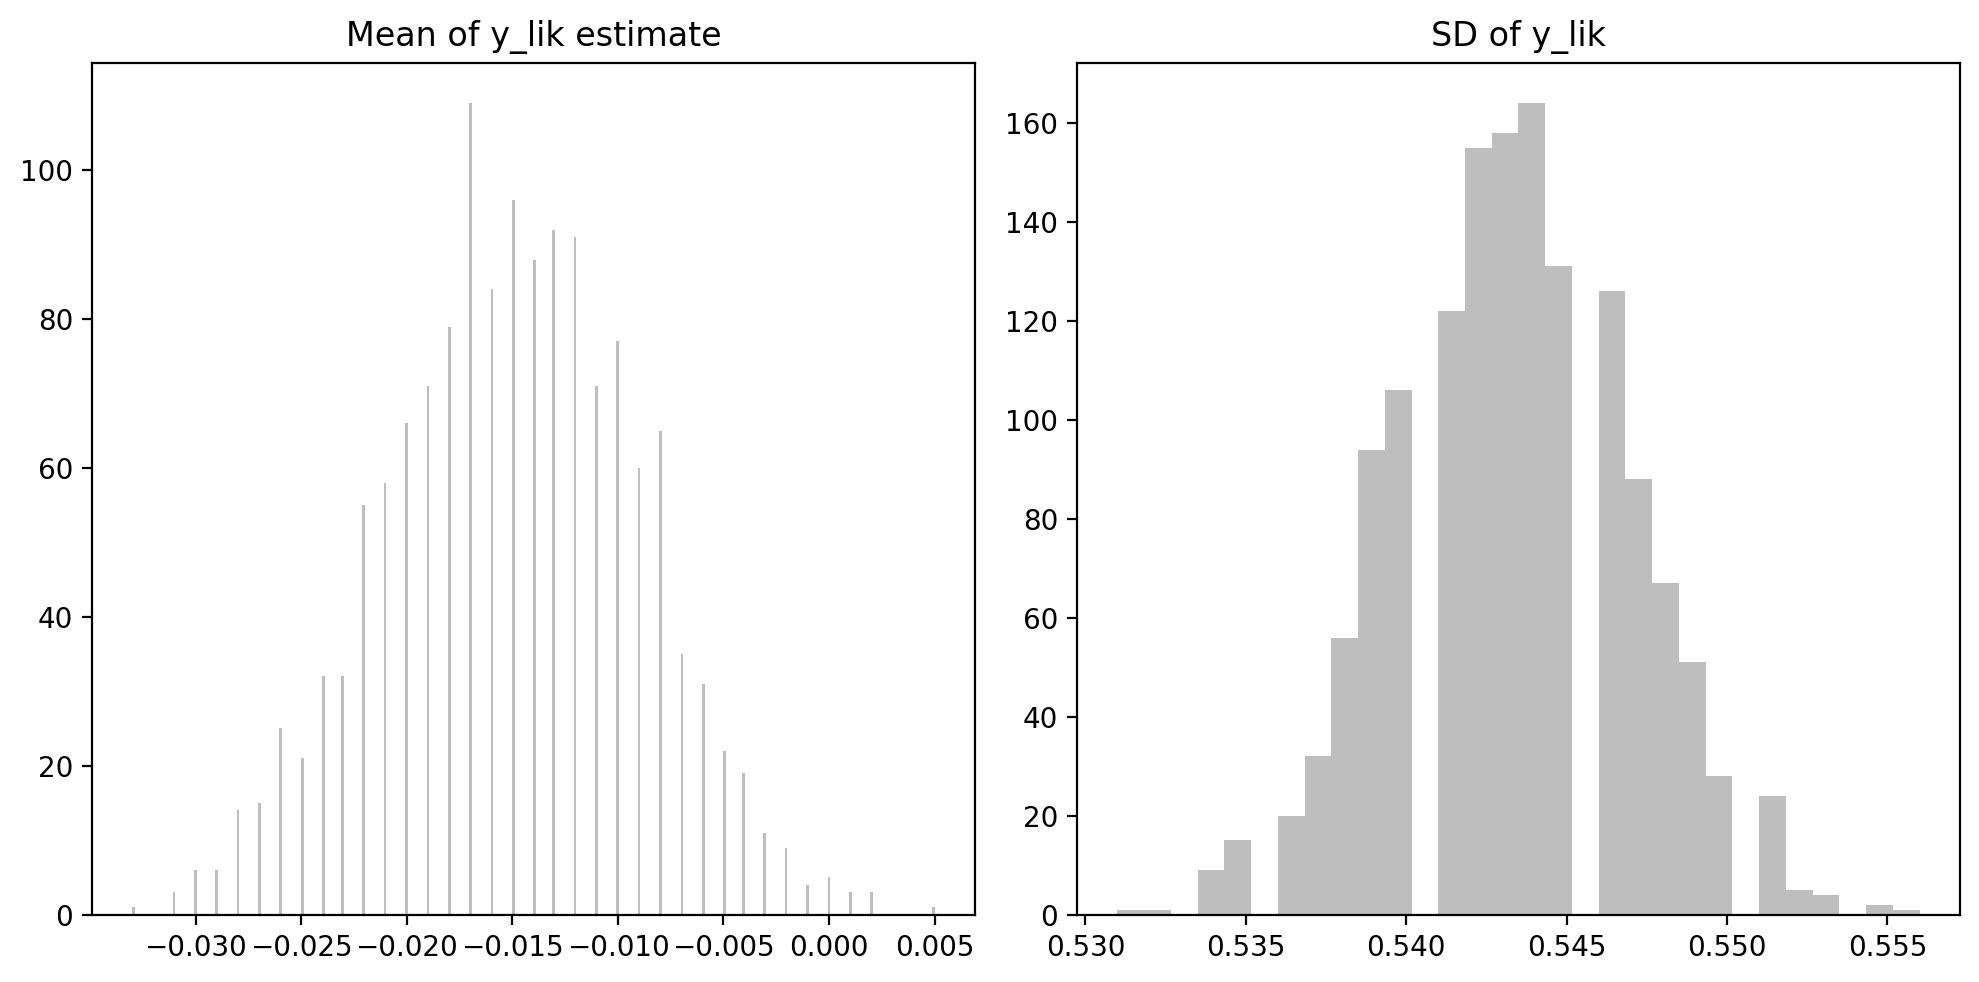

In [41]:

print(pd.DataFrame({
    "mean": [trace_ylik['mean'].mean(), trace_ylik['mean'].std()],
    "sd": [trace_ylik['sd'].mean(), trace_ylik['sd'].std()]
}).set_index(pd.Index(['means', 'sds'])).round(4))

f,ax = plt.subplots(1,2, figsize=(10, 5))
ax = ax.flatten()
ax[0].set_title("Mean of y_lik estimate")
ax[0].hist(trace_ylik['mean'], bins=300, color="tab:grey", alpha=0.5)
#ax[0].set_xlim(-0.05,0.05) # zoom-in on the near-zero peak
ax[1].set_title("SD of y_lik")
ax[1].hist(trace_ylik['sd'], bins=30, color="tab:grey", alpha=0.5)
plt.tight_layout()


Why does it seem to contain a lot of means on zero? Let's find out how many

In [42]:
(trace_ylik['mean'] == 0 ).sum()

np.int64(5)

Well, that was not very informative, but it looks like the peak is very close to the mean (-0.0149), and not zero (upon closer inspection). 

Let's look at the actual values from the trace.

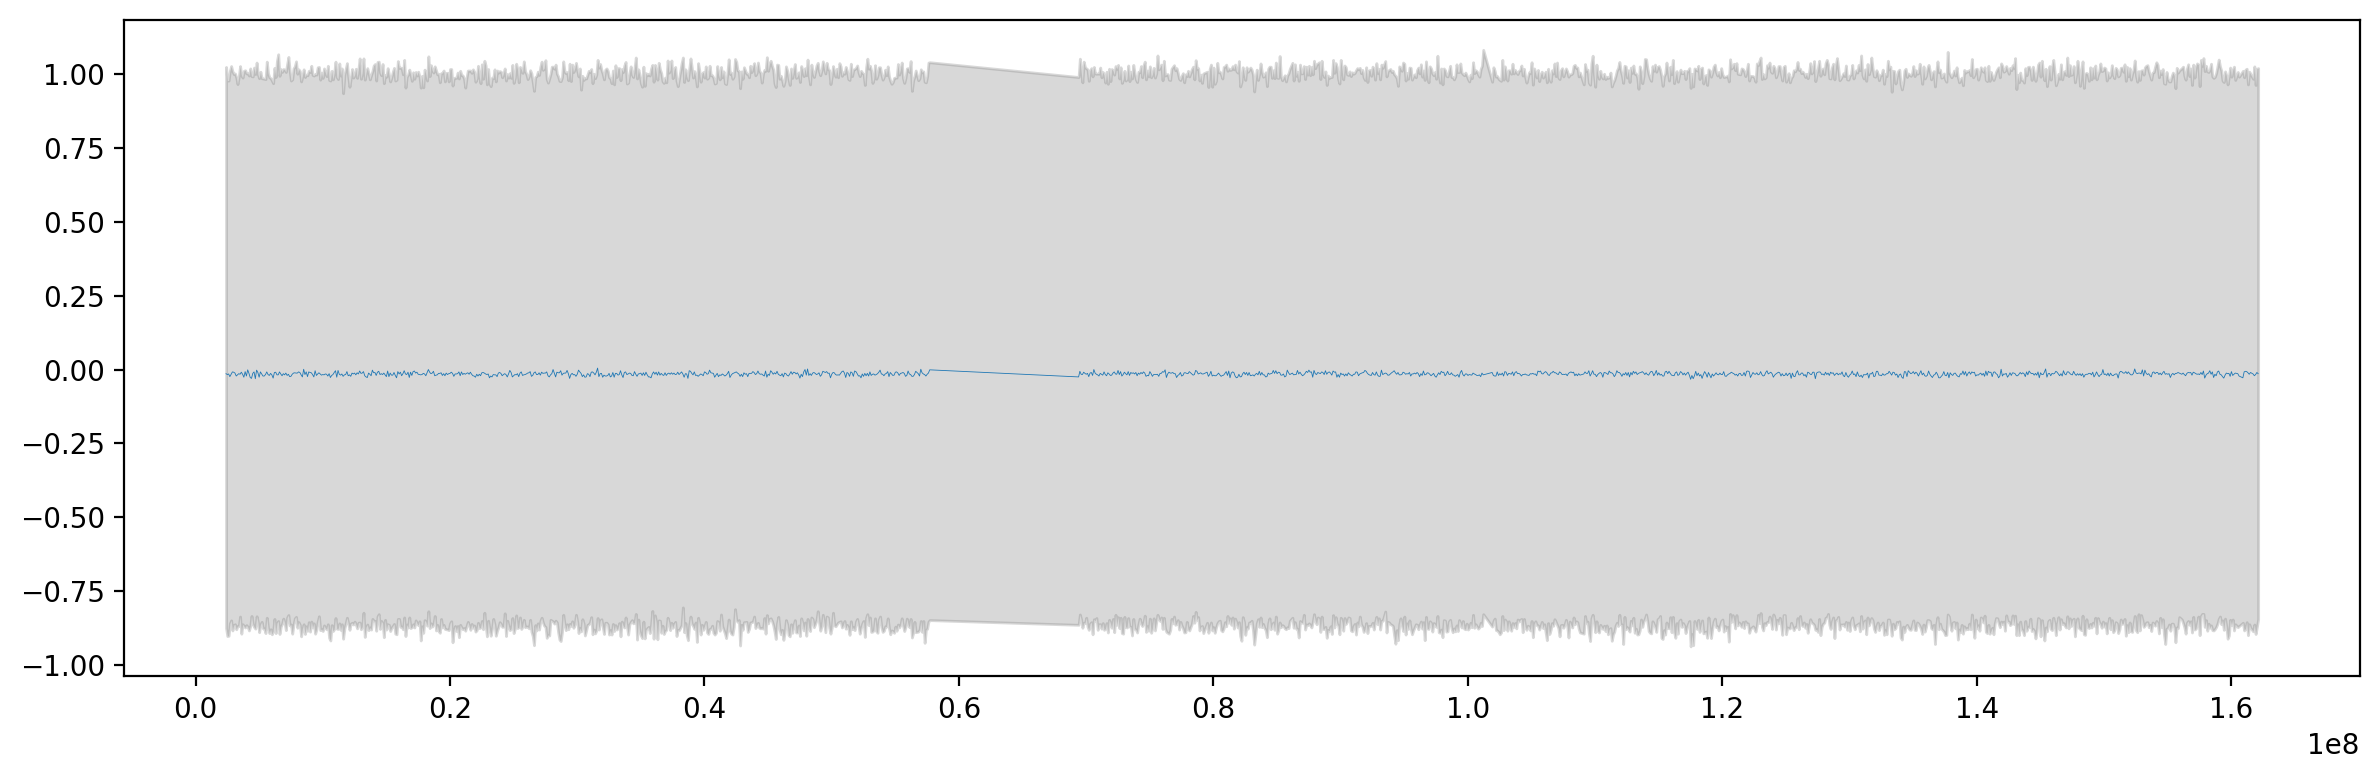

In [43]:


f,ax = plt.subplots(figsize=(12,4))
ax.plot(df['start'], trace_ylik['mean'], lw=0.3, label="prediction confidence")
ax.fill_between(df['start'], trace_ylik['hdi_97%'], trace_ylik['hdi_3%'], color="tab:grey", alpha=0.3, label="95% HDI")
plt.tight_layout()


That looks promising, but we have to look at the predictive samples. 
Let's look at the posterior predictive samples to see how well the model fits the data.

In [44]:
trace.posterior_predictive.stack(sample=("chain", "draw"))

<xarray.Dataset> Size: 94MB
Dimensions:      (y_lik_dim_0: 1460, sample: 8000)
Coordinates:
  * y_lik_dim_0  (y_lik_dim_0) int64 12kB 0 1 2 3 4 ... 1455 1456 1457 1458 1459
  * sample       (sample) object 64kB MultiIndex
  * chain        (sample) int64 64kB 0 0 0 0 0 0 0 0 0 0 ... 3 3 3 3 3 3 3 3 3 3
  * draw         (sample) int64 64kB 0 1 2 3 4 5 ... 1995 1996 1997 1998 1999
Data variables:
    y_lik        (y_lik_dim_0, sample) float64 93MB -0.6359 -0.7648 ... 0.4106
Attributes:
    created_at:                 2025-06-19T12:38:38.315193+00:00
    arviz_version:              0.21.0
    inference_library:          pymc
    inference_library_version:  5.22.0

In [45]:
# p_B = trace.posterior["z"].mean(dim=["chain", "draw"]).values
y_ppc = trace.posterior_predictive["y_lik"]

y_ppc_flat = y_ppc.stack(sample=("chain", "draw"))


ppc_mean = y_ppc_flat.mean(dim="sample").values       # mean of predictions per bin
ppc_std = y_ppc_flat.std(dim="sample").values         # predictive std (uncertainty)
ppc_hdi = az.hdi(y_ppc, hdi_prob=0.95)                # 95% HDI using ArviZ


##### Posterior predictive checks

How does the posterior predictive look? We can visualize the distribution of predicted E1s based on the posterior samples. Here, the mean and sd of the posterior predictive for each bin are visualized in histograms.

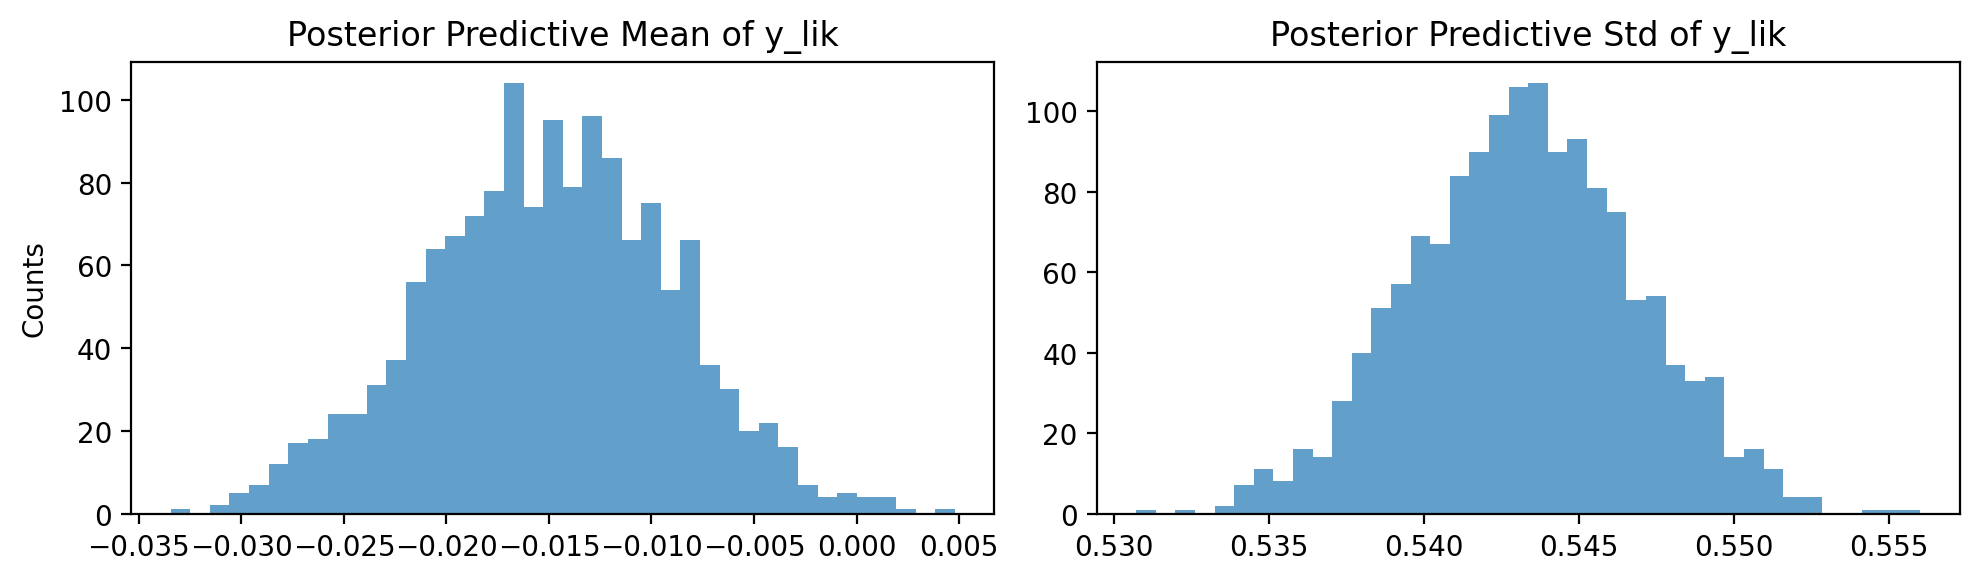

In [46]:
f,ax= plt.subplots(1,2, figsize=(10, 3))
ax[0].set_title("Posterior Predictive Mean of y_lik")
ax[0].set_ylabel("Counts")
ax[0].hist(ppc_mean, bins=40, alpha=0.7, label="Mean(y_lik)")
ax[1].set_title("Posterior Predictive Std of y_lik")
ax[1].hist(ppc_std, bins=40, alpha=0.7, label="Std(y_lik)")
plt.tight_layout()


***~~Full mixture~~*** ~~Hmpf. That was not very promising at all. We would like the posterior predictive to match the observed E1 values, but what we get is a unimodal. Why can that be? The data is modeled as a mixture without a latent binary variable, $z \in {0,1}$.~~

***Latent `z` hard assignment*** Here, we do get a distribution of $\hat{y}$ that somewhat resembles the means of the two suggested distributions for A and B compartments. 


<Axes: xlabel='y_lik'>

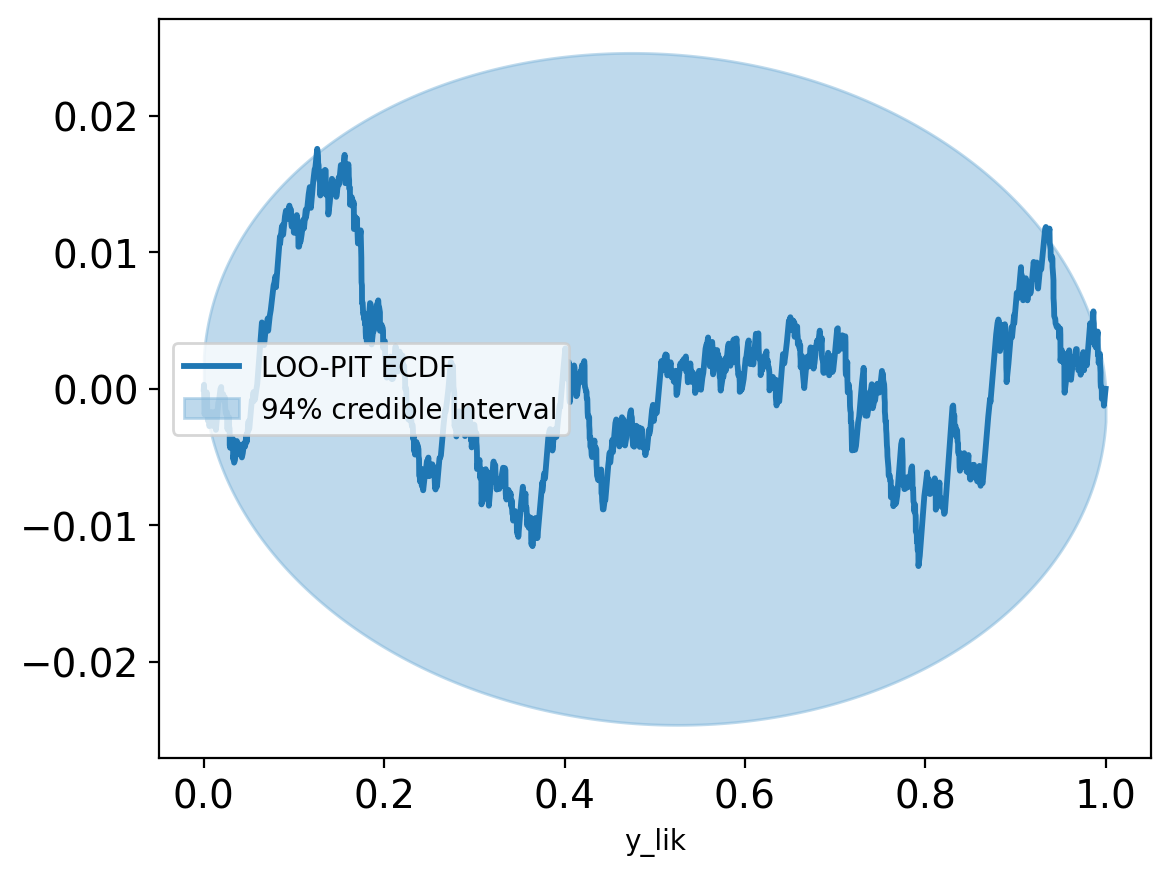

In [47]:
az.plot_loo_pit(trace, y_hat="y_lik", y = "y_lik", ecdf=True)

***Latent `z` model*** Here, there are clear signs of overdispersion, or just something about the structure of the model that does not fit. I'm thinking the model is overdispersed as the bins are i.i.d. There is no limit on the 'walk distance' between the bins, so the model can easily make too large jumps between bins. 

##### Consistency

We can also try to calculate how consistent the predicted E1 is with the observed E1. Maybe this is useful.

In [48]:
trace.posterior_predictive["y_lik"].mean(dim=["chain", "draw"]).values

array([-0.0142628 , -0.01665247, -0.01530841, ..., -0.01669814,
       -0.00994245, -0.01379985], shape=(1460,))

ValueError: could not broadcast input array from shape (1460,) into shape (1623,)

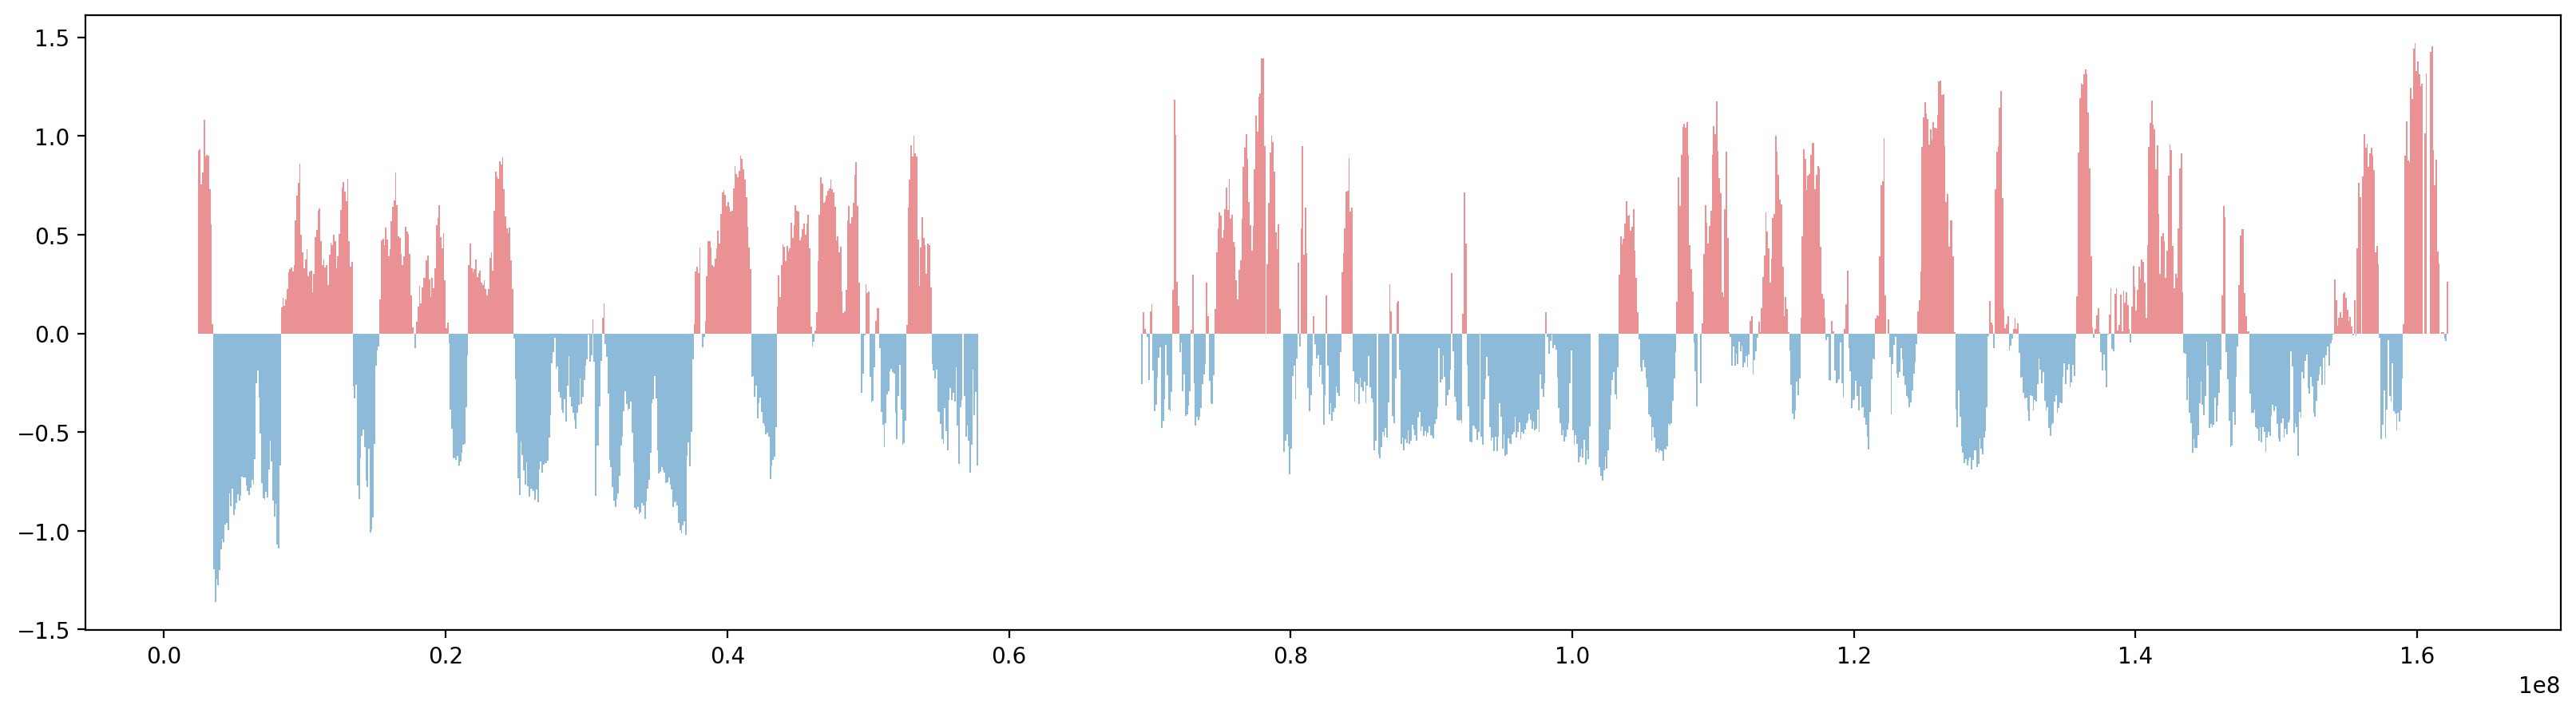

In [49]:
# ppc_mean: shape (bins,)
# mean_ll: shape (bins,)

posterior_mean = trace.posterior_predictive["y_lik"].mean(dim=["chain", "draw"]).values
mean_ll = trace.log_likelihood.y_lik.mean(dim=["chain", "draw"]).values

# Plot the data as a track (stairs for niceity)

fig, ax = plt.subplots(figsize=(20, 5))

# Stairs
x_stair = np.zeros(2*y.shape[0])
y_stair = np.zeros(2*y.shape[0])
x_stair[0::2] = x
x_stair[1::2] = x + resolution
y_stair[0::2] = y
y_stair[1::2] = y

ax.fill_between(x_stair, y_stair, where=(y_stair<0), color="tab:blue", alpha=0.5, ec='None')
ax.fill_between(x_stair, y_stair, where=(y_stair>0), color="tab:red", alpha=0.5, ec='None')

# plot the y_ppc_flat mean
post_mean_stairs = np.zeros(2*y.shape[0])
post_mean_stairs[0::2] = posterior_mean
post_mean_stairs[1::2] = posterior_mean
ax.plot(x_stair, post_mean_stairs, lw=1, label="Posterior Predictive Mean", color="tab:orange")

# Plot the point-wise log-likelihood
ll_stair = np.zeros(2*mean_ll.shape[0])
ll_stair[0::2] = mean_ll
ll_stair[1::2] = mean_ll
ax.plot(x_stair, ll_stair, lw=1, label="Binwise Log-Likelihood", color="tab:green")

ax.set_xlim(0, 57_984_683)
ticks = np.arange(0, 57_984_683, step=5_000_000)
ax.set_xticks(ticks)
ax.set_xticklabels((ticks / 1e6).astype(int), rotation=45)
ax.set_xlabel("Genomic Position (Mbp)")
ax.set_ylabel("E1")
ax.set_title("E1")
ax.legend(loc="best");

ValueError: x and y must have same first dimension, but have shapes (1623,) and (1460,)

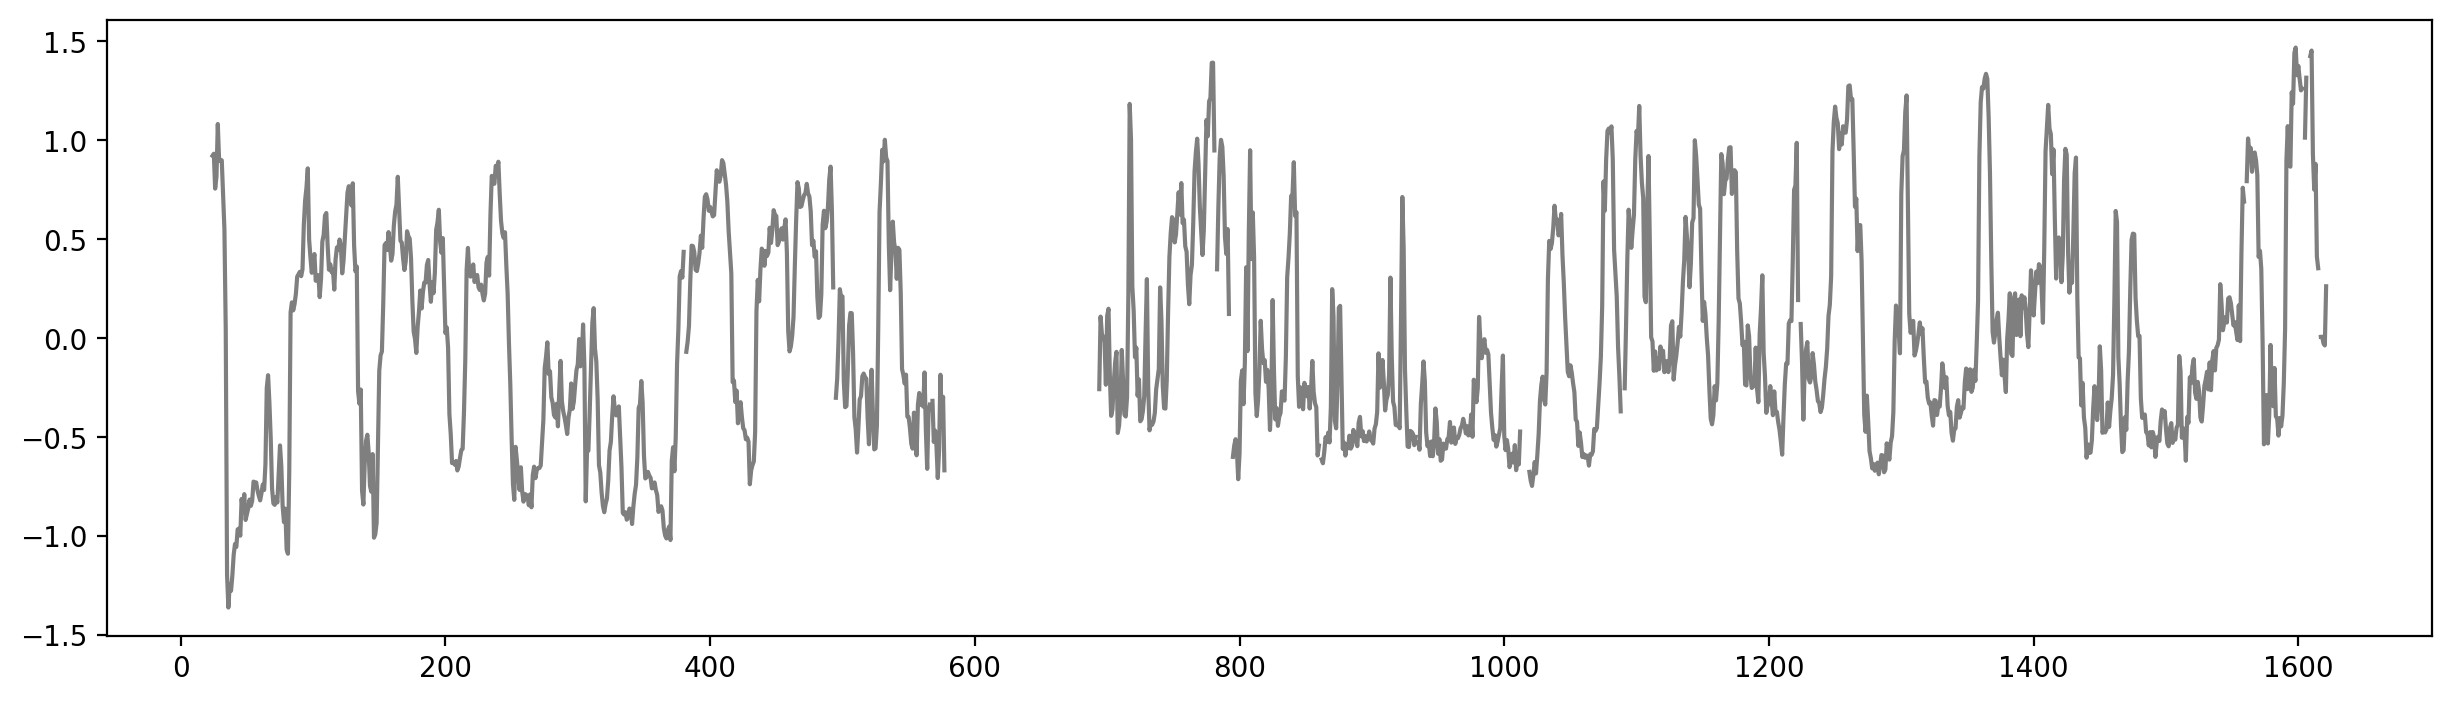

In [50]:
bins = np.arange(len(y))

plt.figure(figsize=(15, 4))

# Observed data
plt.plot(bins, y, label="Observed E1", color="black", alpha=0.5)

# Posterior predictive mean
plt.plot(bins, ppc_mean, label="Posterior Mean", color="tab:red")

# Credible interval shading
plt.fill_between(
    bins,
    ppc_hdi.y_lik.sel(hdi='lower').values,
    ppc_hdi.y_lik.sel(hdi='higher').values,
    color="tab:red",
    alpha=0.3,
    label="95% Credible Interval"
)

plt.xlabel("Genomic bin")
plt.ylabel("E1 value")
plt.title("Posterior Predictive Mean with 95% CI")
plt.legend()
plt.tight_layout()
plt.show()


## Next up: Introducing dependency between bins

In the next [notebook]("03_PyMC_GRW_logit.ipynb"), we will implement a Gaussian Random Walk (GRW) model to introduce spatial dependency between bins. We will investigate how it affects smoothing and uncertainty in compartment assignment. 

We will update the model to 

\begin{aligned}
p_t &\sim \mathcal{N}(p_{t-1}, \sigma^2_{t-1}) \\
z_t &\sim \text{Bernoulli}(p_t) \\ \\
\mu_{z_t} &= z_t \cdot \mu_A + (1 - z_t) \cdot \mu_B \\
y_t &\sim \mathcal{N}(\mu_{z_t}, \sigma^2)
\end{aligned}